# Datasets and Dataloaders

In [2]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

import os
import pandas as pd
from torchvision.io import decode_image

from torch.utils.data import DataLoader

## Loading the data

#### **IMPORTANT**
- Data should be handled separately from the main AI and other functions, creating a new class and functions is often better.

In [3]:
# Loading MNIST for image recognition basics
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

## Visualizing and running through dataset

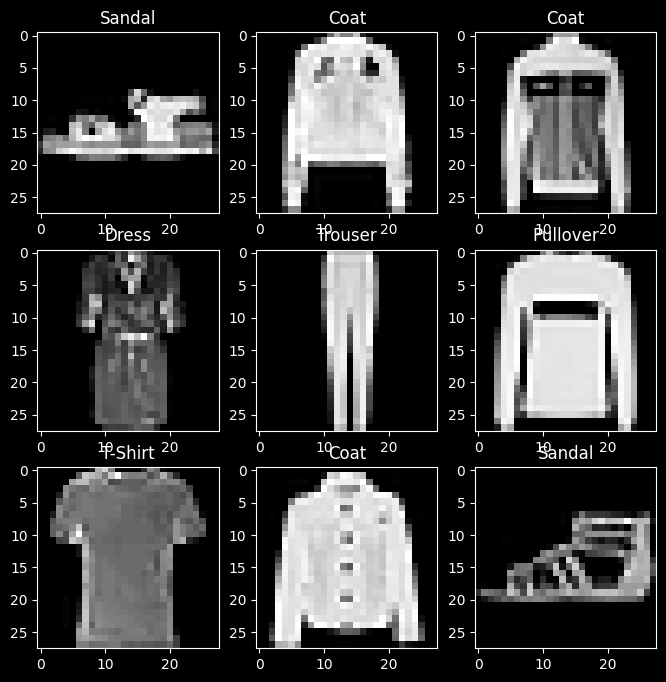

In [4]:
# Showing what's in the dataset
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols*rows + 1):
    #Get random index as tensor to use to get sample images from dataset.
    sample_idx = torch.randint(len(training_data), size=(1,)).item()

    #Split the training data into the image portion and the label portion

    #print(training_data[sample_idx]) -> stored as tensor and y (output) value

    img, label = training_data[sample_idx] # img is tensor value derived from pixels, label is the output value as a numeric (correlates with labels_map)
    # print(img)
    # print()
    # print(label)

    figure.add_subplot(rows, cols, i)

    plt.title(labels_map[label])

    plt.imshow(img.squeeze(), cmap="gray") # plot/show image

plt.show() # Show the matplotlib graph with the random sample images

## Custom datasets

The FasionMNIST is stored as images in one directory and their labels stored in a CSV file (pandas is great at reading these)

#### Again, a custom dataset class is very helpful:
- Each class must inherit from dataset
- Three functions:
    - __init__
    - __len__
    - __getitem__

In [5]:
#Class implementation generic example (FashionMNIST)

#CSV looks like:
# tshirt1.jpg, 0
# tshirt2.jpg, 0
# ......
# ankleboot999.jpg, 9
class CustomImageDataset(Dataset): #Inherits from dataset
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file) # Image labels are gotten from CSV
        self.img_dir = img_dir
        self.transform = transform # dictate what kind of transform ex: to tensor
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0]) # the first item in the pandas dataset is gotten, which is the directory in column 0.
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

## Preparing for training

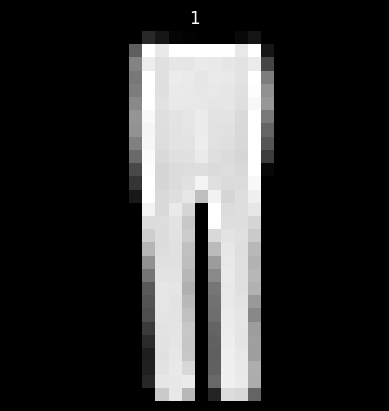

Item is: Trouser


In [44]:
# Dataloader - this autofills in pycharm if wanted

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

train_features, train_labels = next(iter(train_dataloader))

# Display image and label
img = train_features[0].squeeze()
label = train_labels[0].item() # .item converts away from Tensor object
plt.imshow(img, cmap="gray")
plt.title(label)
plt.axis('off')
plt.show()
print(f"Item is: {labels_map[label]}")